In [1]:
import pandas as pd
import os
import sys
sys.path.append(r'D:\code\github\strainOptimizer')
from strainOptimizer.analysis.dataset import calculate_exp_consistency,load_experiment_targets
import numpy as np

# set work dir
os.chdir(r'D:\code\github\strainOptimizer')

In [2]:
def fcc_filter(df):

    # fill abosulte value < 10e-7 as 0
    df['FCCp']=df['FCCp'].apply(lambda x: 0 if abs(x)<10e-7 else x)

    keep_list=[]
    # OE: action=OE, FCCp>0
    oe_list=df[(df['action']=='OE') & (df['FCCp']>0)].index.tolist()
    # KD,KO: action = KD or KO; FCCp < 0
    kd_ko_list=df[(df['action'].isin(['KD','KO'])) & (df['FCCp']<0)].index.tolist()

    df_filtered=df[df.index.isin(oe_list+kd_ko_list)]
    return df_filtered

def calculate_metrics(df,productName):

    # load experimental data
    exp_data=load_experiment_targets(productName)

    # obtain result from different levels
    # fill inf as nan
    df=df.replace([np.inf, -np.inf], np.nan)
    level1_result=df
    level2_result=df[df['target_priority_leval'].isin([1,2,3])]
    level3_result=df[df['minimal candidates set']==1]
    fcc_filtered_level1_result=fcc_filter(level1_result)

    # calculate average distance and connectivity score
    l1_average_distance=level1_result['distance'].mean(skipna=True) # ignore inf
    l1_connectivity_score=level1_result['count'].mean(skipna=True)
    l2_average_distance=level2_result['distance'].mean(skipna=True)
    l2_connectivity_score=level2_result['count'].mean(skipna=True)
    l3_average_distance=level3_result['distance'].mean(skipna=True)
    l3_connectivity_score=level3_result['count'].mean(skipna=True)
    l1_fcc_average_distance=fcc_filtered_level1_result['distance'].mean(skipna=True)
    l1_fcc_connectivity_score=fcc_filtered_level1_result['count'].median(skipna=True)

    l1_eval=calculate_exp_consistency(predict_result=level1_result,exp_data=exp_data,show=False)
    l2_eval=calculate_exp_consistency(predict_result=level2_result,exp_data=exp_data,show=False)
    l3_eval=calculate_exp_consistency(predict_result=level3_result,exp_data=exp_data,show=False)
    l1_fcc_eval=calculate_exp_consistency(predict_result=fcc_filtered_level1_result,exp_data=exp_data,show=False)

    full_result_dict={'l1':l1_eval,'l2':l2_eval,'l3':l3_eval,'fcc':l1_fcc_eval}

    # calculate
    l1_consistency=l1_eval['overall']['consistency']
    l1_precision=l1_eval['overall']['precision']
    l1_predict_num=l1_eval['overall']['predict_num']
    l2_consistency=l2_eval['overall']['consistency']
    l2_precision=l2_eval['overall']['precision']
    l2_predict_num=l2_eval['overall']['predict_num']
    l3_consistency=l3_eval['overall']['consistency']
    l3_precision=l3_eval['overall']['precision']
    l3_predict_num=l3_eval['overall']['predict_num']
    l1_fcc_consistency=l1_fcc_eval['overall']['consistency']
    l1_fcc_precision=l1_fcc_eval['overall']['precision']
    l1_fcc_predict_num=l1_fcc_eval['overall']['predict_num']

    metrics_dict={'l1_consistency':l1_consistency,
                  'l1_precision':l1_precision,
                  'l1_predict_num':l1_predict_num,
                  'l1_average_distance':l1_average_distance,
                  'l1_connectivity_score':l1_connectivity_score,
                  'l2_consistency':l2_consistency,
                  'l2_precision':l2_precision,
                  'l2_predict_num':l2_predict_num,
                  'l2_average_distance':l2_average_distance,
                  'l2_connectivity_score':l2_connectivity_score,
                  'l3_consistency':l3_consistency,
                  'l3_precision':l3_precision,
                  'l3_predict_num':l3_predict_num,
                  'l3_average_distance':l3_average_distance,
                  'l3_connectivity_score':l3_connectivity_score,
                  'fcc_consistency':l1_fcc_consistency,
                  'fcc_precision':l1_fcc_precision,
                  'fcc_predict_num':l1_fcc_predict_num,
                  'fcc_average_distance':l1_fcc_average_distance,
                  'fcc_connectivity_score':l1_fcc_connectivity_score,
                  }
    return metrics_dict,full_result_dict

In [3]:
full_results_dict={'yes':{},'no':{},'without mitochondria':{}}
slim_result_df=pd.DataFrame()
for file in os.listdir(r'analysis_code\results\organelle_proteomic_constraints'):
    if file.endswith('.xlsx'):
        if 'gluc_10_bounds' not in file:
            continue
        model_type=file.split('_')[0]
        product_name=file.split('_')[1]
        if 'no_mitcho' in file:
            organelle_constraint='without mitochondria'
        else:
            organelle_constraint='yes'

        # load predicted result
        df=pd.read_excel(f'analysis_code/results/organelle_proteomic_constraints/{file}',sheet_name='geneTable',index_col=0)
        # remove removed by EUVA in target_priority_leval column
        df=df[df['target_priority_leval']!='removed by EUVA']
       
         # load experimental result
        if product_name=='free fatty acids':
            product_name='ffa'

        result_dict={'model_type':model_type,'product_name':product_name,'organelle_constraint':organelle_constraint}
       # calculate metrics
        metrics_dict,full_result_dict=calculate_metrics(df,product_name)

        result_dict.update(metrics_dict)
        slim_result_df=pd.concat([slim_result_df,pd.DataFrame([result_dict])],ignore_index=True)

        full_results_dict[organelle_constraint][product_name]=full_result_dict


# add ppfba result
for file in os.listdir(r'analysis_code\results/ecGEM_vs_efl'):
    if file.endswith('.xlsx'):
        if 'ecGEM' not in file:
            continue
        model_type=file.split('_')[0]
        product_name=file.split('_')[1]
        organelle_constraint='no'



        # load predicted result
        df=pd.read_excel(f'analysis_code/results/ecGEM_vs_efl/{file}',sheet_name='geneTable',index_col=0)

        if product_name=='free fatty acids':
            product_name='ffa'        
        result_dict={'model_type':model_type,'product_name':product_name,'organelle_constraint':organelle_constraint}
        exp_data=load_experiment_targets(product_name)

        # calculate experiment consistency
        eval_result=calculate_exp_consistency(df,exp_data,show=False)

        # calculate metrics
        metrics_dict,full_result_dict=calculate_metrics(df,product_name)

        result_dict.update(metrics_dict)
        slim_result_df=pd.concat([slim_result_df,pd.DataFrame([result_dict])],ignore_index=True)

        full_results_dict[organelle_constraint][product_name]=full_result_dict


In [ ]:
slim_result_df

,model_type,product_name,organelle_constraint,l1_consistency,l1_precision,l1_predict_num,l1_average_distance,l1_connectivity_score,l2_consistency,l2_precision,...,l3_consistency,l3_precision,l3_predict_num,l3_average_distance,l3_connectivity_score,fcc_consistency,fcc_precision,fcc_predict_num,fcc_average_distance,fcc_connectivity_score
0,ecGEM,2-phenylethanol,yes,0.538462,0.095890,73,6.113514,19.479452,0.538462,0.116667,...,0.384615,0.217391,23,6.300000,8.782609,0.307692,0.400000,10,5.890000,12.5
1,ecGEM,2-phenylethanol,without mitochondria,0.538462,0.125000,56,6.149658,22.714286,0.538462,0.159091,...,0.384615,0.555556,9,6.009091,17.555556,0.307692,0.400000,10,6.190000,13.5
2,ecGEM,ffa,yes,0.277778,0.096154,52,6.835258,25.269231,0.166667,0.076923,...,0.111111,0.133333,15,7.339762,19.266667,0.055556,0.100000,10,6.062500,13.0
3,ecGEM,ffa,without mitochondria,0.222222,0.051948,77,7.630133,11.878378,0.111111,0.034483,...,0.055556,0.029412,34,8.500000,4.205882,0.055556,0.090909,11,7.035354,5.0
4,ecGEM,heme,yes,0.263158,0.238095,42,7.159890,36.712644,0.236842,0.290323,...,0.184211,0.777778,9,6.538462,8.692308,0.236842,0.692308,13,5.692308,3.0
5,ecGEM,heme,without mitochondria,0.236842,0.112500,80,7.550752,10.291139,0.236842,0.142857,...,0.184211,0.175000,40,7.807273,5.275000,0.236842,0.529412,17,6.250000,3.0
6,ecGEM,sclareol,yes,0.272727,0.088235,68,7.255268,39.833333,0.136364,0.061224,...,0.045455,0.111111,9,6.020833,12.555556,0.045455,0.250000,4,4.875000,8.5
7,ecGEM,sclareol,without mitochondria,0.181818,0.050633,79,7.334121,39.115385,0.136364,0.051724,...,0.045455,0.142857,7,5.750000,10.000000,0.045455,0.250000,4,4.875000,8.5
8,ecGEM,spermidine,yes,0.380952,0.086022,93,6.439035,31.849462,0.285714,0.082192,...,0.190476,0.200000,20,6.445833,32.200000,0.047619,0.333333,3,7.333333,32.0
9,ecGEM,spermidine,without mitochondria,0.333333,0.084337,83,6.489826,33.771084,0.238095,0.074627,...,0.190476,0.200000,20,6.392424,30.550000,0.047619,0.500000,2,7.000000,25.5


In [6]:
slim_result_df

df_result=pd.DataFrame(columns=['model_type','product_name','organelle_constraint','level','consistency','precision','predict_num','average_distance','connectivity_score'])
for index,row in slim_result_df.iterrows():
    model_type=row['model_type']
    product_name=row['product_name']
    organelle_constraint=row['organelle_constraint']
    prefixList=['l1','l2','l3','fcc']
    for prefix in prefixList:
        columns=[item for item in row.keys() if item.startswith(prefix)]
        values=row[columns].values.tolist()
        values=[model_type,product_name,organelle_constraint,prefix]+values
        df_result=pd.concat([df_result,pd.DataFrame([values],columns=df_result.columns)],ignore_index=True)

df_result.to_csv(r'analysis_code\results/ecGEM_organelle_proteome_constraint_evaluation.csv')
df_result.head()

C:\Users\wangh\AppData\Local\Temp\ipykernel_20944\3941373677.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_result=pd.concat([df_result,pd.DataFrame([values],columns=df_result.columns)],ignore_index=True)


,model_type,product_name,organelle_constraint,level,consistency,precision,predict_num,average_distance,connectivity_score
0,ecGEM,2-phenylethanol,yes,l1,0.538462,0.095890,73,6.113514,19.479452
1,ecGEM,2-phenylethanol,yes,l2,0.538462,0.116667,60,6.053352,19.833333
2,ecGEM,2-phenylethanol,yes,l3,0.384615,0.217391,23,6.300000,8.782609
3,ecGEM,2-phenylethanol,yes,fcc,0.307692,0.400000,10,5.890000,12.500000
4,ecGEM,2-phenylethanol,without mitochondria,l1,0.538462,0.125000,56,6.149658,22.714286


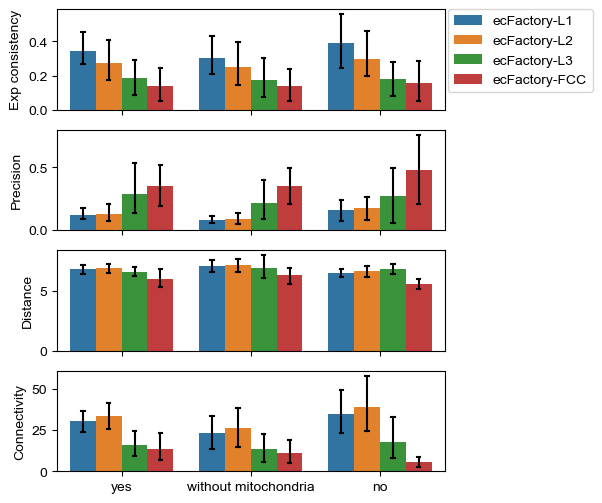

In [83]:
# plot the barplots for consistency, accuracy and predict num
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# slim_result_df=pd.read_csv(r'analysis_code/results/slim_result_df.csv')
# plot the barplots for consistency, accuracy and predict num and hue by model_type
fig,axs=plt.subplots(4,1,figsize=(5,6))

# plot experiment constency
sns.barplot(x='organelle_constraint',y='consistency',hue='level',data=df_result,ax=axs[0],capsize=0.1,err_kws={'linewidth':1.5,'color':'black'})
# sns.boxplot(x='model_type',y='consistency',hue='level',data=df_result,ax=axs[0],showfliers=False)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Exp consistency')
# set legend outside and content as : l1:ecFactory-L1, l2: ecFactory-L2, l3: ecFactory-L3, fcc: ecFactory-FCC
label_map = {
    'l1': 'ecFactory-L1',
    'l2': 'ecFactory-L2',
    'l3': 'ecFactory-L3',
    'fcc': 'ecFactory-FCC'
}
handles, labels = axs[0].get_legend_handles_labels()
new_labels = [label_map.get(l, l) for l in labels]
axs[0].legend(
    handles,
    new_labels,
    # title='Level',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0.
)

# plot experiment accuracy
sns.barplot(x='organelle_constraint',y='precision',hue='level',data=df_result,ax=axs[1],legend=False,capsize=0.1,err_kws={'linewidth':1.5,'color':'black'})
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision')


# plot average distance
sns.barplot(x='organelle_constraint',y='average_distance',hue='level',data=df_result,ax=axs[2],legend=False,capsize=0.1,err_kws={'linewidth':1.5,'color':'black'})
axs[2].set_xlabel('')
axs[2].set_xticklabels([])
axs[2].set_ylabel('Distance')

# plot average connectivity
sns.barplot(ax=axs[3],x='organelle_constraint',y='connectivity_score',hue='level',data=df_result,legend=False,capsize=0.1,err_kws={'linewidth':1.5,'color':'black'})
axs[3].set_xlabel('')
# axs[3].set_xticklabels(['no','yes'])
axs[3].set_ylabel('Connectivity')
# set title
# fig.suptitle('Evaluation of ecGEM and EFL')
plt.show()

C:\Users\wangh\AppData\Local\Temp\ipykernel_36412\932971936.py:17: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='consistency',hue='organelle_constraint',data=df_select,ax=axs[0],order=product_name_order.keys(),palette=palette)
C:\Users\wangh\AppData\Local\Temp\ipykernel_36412\932971936.py:26: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='precision',hue='organelle_constraint',data=df_select,ax=axs[1],legend=False,order=product_name_order.keys(),palette=palette)
C:\Users\wangh\AppData\Local\Temp\ipykernel_36412\932971936.py:34: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='predict_num',hue='organelle_constraint',data=df_select,ax=axs[2],legend=False,order=product_name_order.keys(),palette=palette)
C:\Users\wangh\AppData\Local\Temp\ipykernel_36

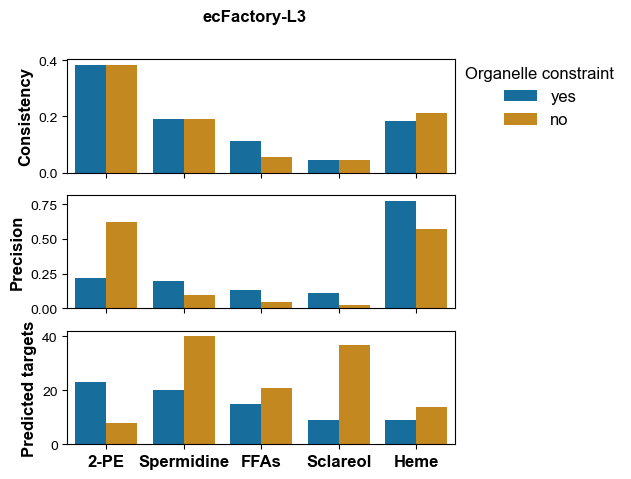

In [89]:
# plot the barplots for consistency, accuracy and predict num 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# set fontstyle as Arial
plt.rcParams['font.family'] = 'Arial'
palette=sns.color_palette("colorblind")

df_select=df_result[df_result['level']=='l3']
df_select=df_select[df_select['organelle_constraint']!='without mitochondria']

fig,axs=plt.subplots(3,1,figsize=(5,5))

product_name_order ={'2-phenylethanol':0,'spermidine':1,'ffa':2,'sclareol':3,'heme':4}
# plot experiment constency
sns.barplot(x='product_name',y='consistency',hue='organelle_constraint',data=df_select,ax=axs[0],order=product_name_order.keys(),palette=palette)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Consistency',fontweight='bold',fontsize=12)
# set legend outside 
axs[0].legend(title='Organelle constraint',bbox_to_anchor=(1.01, 1), borderaxespad=0.,fontsize=12,title_fontsize=12,frameon=False)

# plot experiment accuracy
sns.barplot(x='product_name',y='precision',hue='organelle_constraint',data=df_select,ax=axs[1],legend=False,order=product_name_order.keys(),palette=palette)
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision',fontweight='bold',fontsize=12)


# plot experiment predict num
sns.barplot(x='product_name',y='predict_num',hue='organelle_constraint',data=df_select,ax=axs[2],legend=False,order=product_name_order.keys(),palette=palette)
# set x, y ticks
# set x ticks
x_ticks_dict={'2-phenylethanol':'2-PE',
              'heme':'Heme',
              'ffa':'FFAs',
              'sclareol':'Sclareol',
              'spermidine':'Spermidine'}
x_ticks_list=[x_ticks_dict[i] for i in product_name_order.keys()]
axs[2].set_xticklabels(rotation=0,labels=x_ticks_list,fontweight='bold',fontsize=12)
axs[2].set_xlabel('')
axs[2].set_ylabel('Predicted targets',fontweight='bold',fontsize=12)

fig.suptitle('ecFactory-L3',fontweight='bold',fontsize=12)
# plt.tight_layout()
# save it
# fig.savefig('organelle_proteome_constraint_evaluation.png',dpi=300,bbox_inches='tight')
plt.show()

C:\Users\wangh\AppData\Local\Temp\ipykernel_36412\4029825001.py:8: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='consistency',hue='organelle_constraint',data=df_select,ax=axs[0],order=product_name_order.keys(),palette=palette)
C:\Users\wangh\AppData\Local\Temp\ipykernel_36412\4029825001.py:17: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='precision',hue='organelle_constraint',data=df_select,ax=axs[1],legend=False,order=product_name_order.keys(),palette=palette)
C:\Users\wangh\AppData\Local\Temp\ipykernel_36412\4029825001.py:25: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='predict_num',hue='organelle_constraint',data=df_select,ax=axs[2],legend=False,order=product_name_order.keys(),palette=palette)
C:\Users\wangh\AppData\Local\Temp\ipykernel_

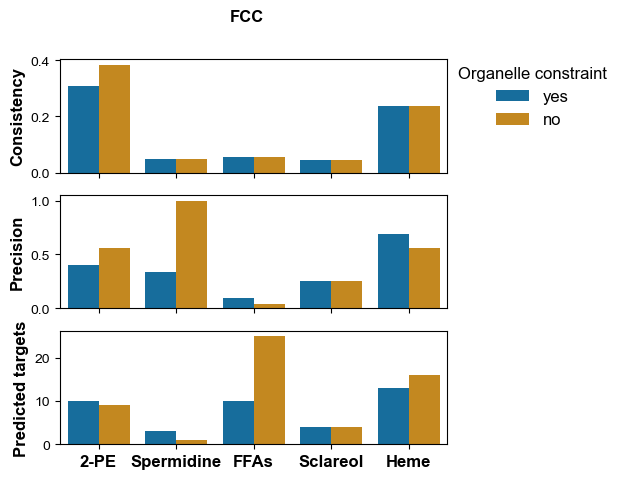

In [90]:
df_select=df_result[df_result['level']=='fcc']
df_select=df_select[df_select['organelle_constraint']!='without mitochondria']

fig,axs=plt.subplots(3,1,figsize=(5,5))

product_name_order ={'2-phenylethanol':0,'spermidine':1,'ffa':2,'sclareol':3,'heme':4}
# plot experiment constency
sns.barplot(x='product_name',y='consistency',hue='organelle_constraint',data=df_select,ax=axs[0],order=product_name_order.keys(),palette=palette)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Consistency',fontweight='bold',fontsize=12)
# set legend outside 
axs[0].legend(title='Organelle constraint',bbox_to_anchor=(1.01, 1), borderaxespad=0.,fontsize=12,title_fontsize=12,frameon=False)

# plot experiment accuracy
sns.barplot(x='product_name',y='precision',hue='organelle_constraint',data=df_select,ax=axs[1],legend=False,order=product_name_order.keys(),palette=palette)
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision',fontweight='bold',fontsize=12)


# plot experiment predict num
sns.barplot(x='product_name',y='predict_num',hue='organelle_constraint',data=df_select,ax=axs[2],legend=False,order=product_name_order.keys(),palette=palette)
# set x, y ticks
# set x ticks
x_ticks_dict={'2-phenylethanol':'2-PE',
              'heme':'Heme',
              'ffa':'FFAs',
              'sclareol':'Sclareol',
              'spermidine':'Spermidine'}
x_ticks_list=[x_ticks_dict[i] for i in product_name_order.keys()]
axs[2].set_xticklabels(rotation=0,labels=x_ticks_list,fontweight='bold',fontsize=12)
axs[2].set_xlabel('')
axs[2].set_ylabel('Predicted targets',fontweight='bold',fontsize=12)

fig.suptitle('FCC',fontweight='bold',fontsize=12)
# plt.tight_layout()
# save it
# fig.savefig('organelle_proteome_constraint_evaluation.png',dpi=300,bbox_inches='tight')
plt.show()

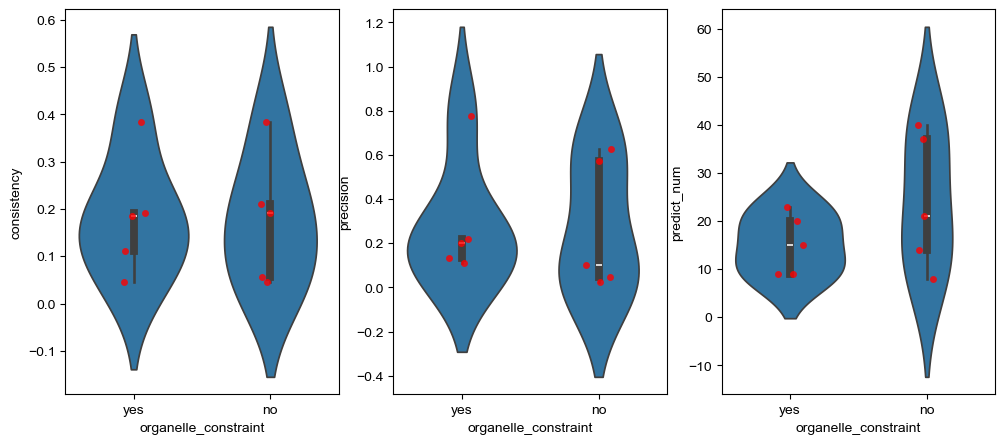

In [45]:
fig,axs=plt.subplots(1,3,figsize=(12,5))

sns.violinplot(x='organelle_constraint',y='consistency',data=df_select,ax=axs[0],legend=False)
# show the points
sns.stripplot(x='organelle_constraint',y='consistency',data=df_select,ax=axs[0],color='red',alpha=0.8)

sns.violinplot(x='organelle_constraint',y='precision',data=df_select,ax=axs[1],legend=False)
# show the points
sns.stripplot(x='organelle_constraint',y='precision',data=df_select,ax=axs[1],color='red',alpha=0.8)

sns.violinplot(x='organelle_constraint',y='predict_num',data=df_select,ax=axs[2],legend=False)
# show the points
sns.stripplot(x='organelle_constraint',y='predict_num',data=df_select,ax=axs[2],color='red',alpha=0.8)

plt.show()

In [91]:
# plot heme a prediction performance
df_heme=df_result[df_result['product_name']=='heme']
df_heme_l3=df_heme[df_heme['level']=='l3']
df_heme_fcc=df_heme[df_heme['level']=='fcc']
df_heme_fcc

,model_type,product_name,organelle_constraint,level,consistency,precision,predict_num,average_distance,connectivity_score
19,ecGEM,heme,yes,fcc,0.236842,0.692308,13,5.692308,3.0
23,ecGEM,heme,without mitochondria,fcc,0.236842,0.529412,17,6.250000,3.0
51,ecGEM,heme,no,fcc,0.236842,0.562500,16,5.783333,3.0


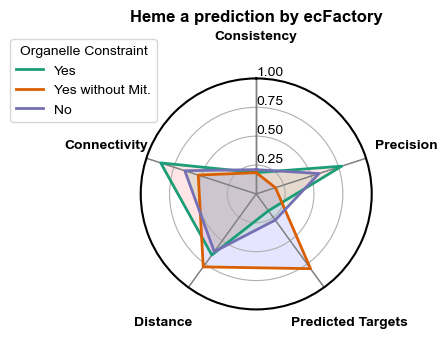

,model_type,product_name,organelle_constraint,level,consistency,precision,predict_num,average_distance,connectivity_score
18,ecGEM,heme,yes,l3,0.184211,0.777778,0.18,0.653846,0.869231
22,ecGEM,heme,without mitochondria,l3,0.184211,0.175000,0.8,0.780727,0.527500
50,ecGEM,heme,no,l3,0.210526,0.571429,0.28,0.617857,0.650000


In [122]:
from math import pi
colors_set=sns.color_palette('Dark2')
colors_set
# plot radar chart
fig,ax=plt.subplots(figsize=(4,3),subplot_kw=dict(polar=True,frameon=True))
# plt.style.use('seaborn-paper')

# number of variable
categories=['consistency','precision','predict_num','average_distance','connectivity_score']
scale_factors=[1,1,50,10,10]
# scaling the data
df_data_scaled=df_heme_l3.copy()
df_data_scaled[categories]=df_data_scaled[categories]/scale_factors
N = len(categories)

# What will be the angle of each axis in the plot? (we divide the plot / number of variable)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Draw one axis per variable + add labels, set the label position, and make tick labels farther apart
# plt.xticks(angles[:-1], categories, size=10,fontweight="bold",color="black")
plt.xticks(angles[:-1], ['Consistency','Precision','Predicted Targets','Distance','Connectivity'], size=10,fontweight="bold",color="black",
           position=(0, -0.2))
# set x axis line color
ax.spines['polar'].set_color('black')
ax.spines['polar'].set_linewidth(1.5)

# Draw ylabels
ax.set_rlabel_position(0) 
plt.yticks([0.25,0.50,0.75,1.00], size=10)
# don't show tick
# ax.set_yticks([])

plt.ylim(0, 1)

# plot 5 line x=angles,y=1
for angle in angles:
    ax.plot([angle, angle], [0, 1], linewidth=1, linestyle='solid', color='grey')

# Add constrint
values = df_data_scaled[df_data_scaled['organelle_constraint']=='yes'][categories].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Yes",color=colors_set[0])
ax.fill(angles, values, 'red', alpha=0.1)

# yes without mitochondria
values = df_data_scaled[df_data_scaled['organelle_constraint']=='without mitochondria'][categories].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Yes without Mit.",color=colors_set[1])
ax.fill(angles, values, 'blue', alpha=0.1)

# No constraint
values = df_data_scaled[df_data_scaled['organelle_constraint']=='no'][categories].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="No",color=colors_set[2])
ax.fill(angles, values, 'green', alpha=0.1)

# set legend for ax
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 1.2),fontsize=10,ncol=1,frameon=True,title='Organelle Constraint')

# set title
plt.title("Heme a prediction by ecFactory",fontsize=12,fontweight="bold",color="black")
plt.show()

df_data_scaled.head()

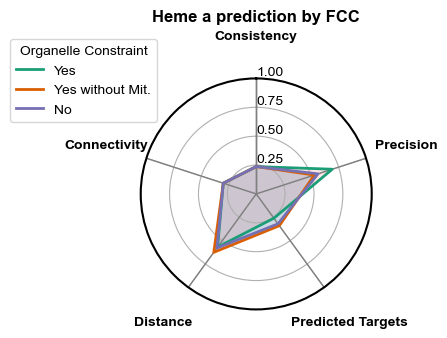

,model_type,product_name,organelle_constraint,level,consistency,precision,predict_num,average_distance,connectivity_score
19,ecGEM,heme,yes,fcc,0.236842,0.692308,13,5.692308,3.0
23,ecGEM,heme,without mitochondria,fcc,0.236842,0.529412,17,6.250000,3.0
51,ecGEM,heme,no,fcc,0.236842,0.562500,16,5.783333,3.0


In [121]:
# plot radar chart
fig,ax=plt.subplots(figsize=(4,3),subplot_kw=dict(polar=True,frameon=True))
# plt.style.use('seaborn-paper')

# number of variable
categories=['consistency','precision','predict_num','average_distance','connectivity_score']
scale_factors=[1,1,50,10,10]
# scaling the data
df_data_scaled=df_heme_fcc.copy()
df_data_scaled[categories]=df_data_scaled[categories]/scale_factors
N = len(categories)

# What will be the angle of each axis in the plot? (we divide the plot / number of variable)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Draw one axis per variable + add labels, set the label position, and make tick labels farther apart
# plt.xticks(angles[:-1], categories, size=10,fontweight="bold",color="black")
plt.xticks(angles[:-1], ['Consistency','Precision','Predicted Targets','Distance','Connectivity'], size=10,fontweight="bold",color="black",
           position=(0, -0.2))
# set x axis line color
ax.spines['polar'].set_color('black')
ax.spines['polar'].set_linewidth(1.5)

# Draw ylabels
ax.set_rlabel_position(0) 
plt.yticks([0.25,0.50,0.75,1.00], size=10)
# don't show tick
# ax.set_yticks([])

plt.ylim(0, 1)

# plot 5 line x=angles,y=1
for angle in angles:
    ax.plot([angle, angle], [0, 1], linewidth=1, linestyle='solid', color='grey')

# Add constrint
values = df_data_scaled[df_data_scaled['organelle_constraint']=='yes'][categories].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Yes",color=colors_set[0])
ax.fill(angles, values, 'red', alpha=0.1)

# yes without mitochondria
values = df_data_scaled[df_data_scaled['organelle_constraint']=='without mitochondria'][categories].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Yes without Mit.",color=colors_set[1])
ax.fill(angles, values, 'blue', alpha=0.1)

# No constraint
values = df_data_scaled[df_data_scaled['organelle_constraint']=='no'][categories].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="No",color=colors_set[2])
ax.fill(angles, values, 'green', alpha=0.1)

# set legend for ax
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 1.2),fontsize=10,ncol=1,frameon=True,title='Organelle Constraint')

# set title
plt.title("Heme a prediction by FCC",fontsize=12,fontweight="bold",color="black")
plt.show()

df_heme_fcc

In [148]:
heme_l3_hit_targets={}
heme_fcc_hit_targets={}
for type,results in full_results_dict.items():
    heme_result=results['heme']
    for level,level_result in heme_result.items():
        if level=='l3':
            false_predicts=[]
            for action in ['KO','OE']:
                hits=level_result[action]['hit']
                predicted_targets=level_result[action]['predict']
                action_false_predicts=list(set(predicted_targets)-set(hits))
                false_predicts+=action_false_predicts
            heme_l3_hit_targets[type]=false_predicts
        elif level=='fcc':
            false_predicts=[]
            for action in ['KO','OE']:
                hits=level_result[action]['hit']
                predicted_targets=level_result[action]['predict']
                action_false_predicts=list(set(predicted_targets)-set(hits))
                false_predicts+=action_false_predicts
            heme_fcc_hit_targets[type]=false_predicts


l3_specific_filtered_genes=set(list(heme_l3_hit_targets['no']))-set(list(heme_l3_hit_targets['yes']))
fcc_specific_filtered_genes=set(list(heme_fcc_hit_targets['no']))-set(list(heme_fcc_hit_targets['yes']))
print('l3 level specific filtered genes: ',l3_specific_filtered_genes)
print('fcc level specific filtered genes: ',fcc_specific_filtered_genes)



l3 level specific filtered genes:  {'YMR220W', 'YMR208W', 'YJL167W', 'YML126C'}
fcc level specific filtered genes:  {'YLR044C', 'YMR220W', 'YMR208W', 'YJL167W'}


In [147]:
heme_l3_hit_targets['yes']

['YDR232W', 'YOR278W']